In [5]:
import pandas as pd
import numpy as np
import spacy
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from scipy import stats

# Настройки графиков
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

print("OK")

OK


In [13]:
# Загрузка датасета
ds = load_dataset("multi_woz_v22", split="train")
print(f"Количество диалогов: {len(ds)}")
print(f"Поля: {ds.features}")

Количество диалогов: 8437
Поля: {'dialogue_id': Value(dtype='string', id=None), 'services': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'turns': Sequence(feature={'turn_id': Value(dtype='string', id=None), 'speaker': ClassLabel(names=['USER', 'SYSTEM'], id=None), 'utterance': Value(dtype='string', id=None), 'frames': Sequence(feature={'service': Value(dtype='string', id=None), 'state': {'active_intent': Value(dtype='string', id=None), 'requested_slots': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None), 'slots_values': Sequence(feature={'slots_values_name': Value(dtype='string', id=None), 'slots_values_list': Sequence(feature=Value(dtype='string', id=None), length=-1, id=None)}, length=-1, id=None)}, 'slots': Sequence(feature={'slot': Value(dtype='string', id=None), 'value': Value(dtype='string', id=None), 'start': Value(dtype='int32', id=None), 'exclusive_end': Value(dtype='int32', id=None), 'copy_from': Value(dtype='string', id=None), 'cop

In [7]:
sample = ds[0]
print("=== Ключи в диалоге ===")
print(list(sample.keys()))

print("\n=== Dialogue ID ===")
print(sample['dialogue_id'])

print("\n=== Структура turns ===")
print(f"Тип: {type(sample['turns'])}")
print(f"Ключи внутри turns: {list(sample['turns'].keys())}")

print("\n=== Первые 4 реплики ===")
for i in range(4):
    speaker = sample['turns']['speaker'][i]
    speaker_name = "USER" if speaker == 0 else "SYSTEM"
    utterance = sample['turns']['utterance'][i]
    print(f"[{speaker_name}] {utterance}")

=== Ключи в диалоге ===
['dialogue_id', 'services', 'turns']

=== Dialogue ID ===
PMUL4398.json

=== Структура turns ===
Тип: <class 'dict'>
Ключи внутри turns: ['turn_id', 'speaker', 'utterance', 'frames', 'dialogue_acts']

=== Первые 4 реплики ===
[USER] i need a place to dine in the center thats expensive
[SYSTEM] I have several options for you; do you prefer African, Asian, or British food?
[USER] Any sort of food would be fine, as long as it is a bit expensive. Could I get the phone number for your recommendation?
[SYSTEM] There is an Afrian place named Bedouin in the centre. How does that sound?


In [19]:
def dialog_to_prefixes(dialog):
    """
    Берёт один диалог и возвращает список dict-ов — по одному на каждый префикс
    каждой USER-реплики.
    
    Пример: реплика "I want a hotel" → 4 префикса:
        ("I",              is_end=0)
        ("I want",         is_end=0)
        ("I want a",       is_end=0)
        ("I want a hotel", is_end=1)
    """
    rows = []
    dialogue_id = dialog['dialogue_id']
    speakers = dialog['turns']['speaker']
    utterances = dialog['turns']['utterance']
    turn_ids = dialog['turns']['turn_id']
    
    for speaker, utterance, turn_id in zip(speakers, utterances, turn_ids):
        if speaker != 0:  # 0 = USER, нам нужны только реплики пользователя
            continue
        text = utterance.strip()
        if not text:
            continue  # пропускаем пустые
        
        words = text.split()
        n = len(words)
        for i in range(1, n + 1):
            prefix = " ".join(words[:i])
            rows.append({
                "dialogue_id": dialogue_id,
                "turn_id": turn_id,
                "prefix_text": prefix,
                "is_end": int(i == n),  # 1 только для последнего префикса
            })
    return rows


# Тест функции на первом диалоге
test_rows = dialog_to_prefixes(ds[0])
print(f"Префиксов в первом диалоге: {len(test_rows)}")
print("\nПервые 8 строк:")
for r in test_rows[:16]:
    print(f"  is_end={r['is_end']}  text={r['prefix_text']!r}")


Префиксов в первом диалоге: 82

Первые 8 строк:
  is_end=0  text='i'
  is_end=0  text='i need'
  is_end=0  text='i need a'
  is_end=0  text='i need a place'
  is_end=0  text='i need a place to'
  is_end=0  text='i need a place to dine'
  is_end=0  text='i need a place to dine in'
  is_end=0  text='i need a place to dine in the'
  is_end=0  text='i need a place to dine in the center'
  is_end=0  text='i need a place to dine in the center thats'
  is_end=1  text='i need a place to dine in the center thats expensive'
  is_end=0  text='Any'
  is_end=0  text='Any sort'
  is_end=0  text='Any sort of'
  is_end=0  text='Any sort of food'
  is_end=0  text='Any sort of food would'


In [21]:
# Ограничимся первыми 2000 диалогами - этого хватит для EDA.
# Позже на этапе моделирования можно увеличить.
N_DIALOGS = 2000

all_rows = []
for dialog in ds.select(range(N_DIALOGS)):
    all_rows.extend(dialog_to_prefixes(dialog))

df = pd.DataFrame(all_rows)
print(f"Всего префиксов: {len(df):,}")
print(f"Уникальных диалогов: {df['dialogue_id'].nunique()}")
print(f"Доля is_end=1: {df['is_end'].mean():.3f}")
print()
df.head(16)


Всего префиксов: 153,983
Уникальных диалогов: 2000
Доля is_end=1: 0.088



,dialogue_id,turn_id,prefix_text,is_end
0,PMUL4398.json,0,i,0
1,PMUL4398.json,0,i need,0
2,PMUL4398.json,0,i need a,0
3,PMUL4398.json,0,i need a place,0
4,PMUL4398.json,0,i need a place to,0
5,PMUL4398.json,0,i need a place to dine,0
6,PMUL4398.json,0,i need a place to dine in,0
7,PMUL4398.json,0,i need a place to dine in the,0
8,PMUL4398.json,0,i need a place to dine in the center,0
9,PMUL4398.json,0,i need a place to dine in the center thats,0


In [23]:
nlp = spacy.load("en_core_web_sm", disable=["ner", "parser", "lemmatizer"])

# Извлечение базовых признаков (быстро, без spaCy)
df['length_words'] = df['prefix_text'].str.split().str.len()
df['length_chars'] = df['prefix_text'].str.len()
df['last_word'] = df['prefix_text'].str.split().str[-1].str.lower()
df['ends_with_punct'] = df['prefix_text'].str.rstrip().str[-1].isin(['.', '?', '!']).astype(int)

# Список вопросительных слов
QUESTION_WORDS = {"what", "where", "when", "who", "why", "how", "which", "whose"}
df['has_question_word'] = df['prefix_text'].str.lower().apply(
    lambda t: int(any(w in t.split() for w in QUESTION_WORDS))
)

# POS-тег последнего слова через spaCy — считаем только для уникальных слов
unique_last_words = df['last_word'].unique()
print(f"Уникальных последних слов: {len(unique_last_words):,}")

pos_map = {}
for doc in nlp.pipe(unique_last_words, batch_size=500):
    if len(doc) > 0:
        pos_map[doc.text] = doc[0].pos_
    else:
        pos_map[doc.text] = "X"  # неизвестно

df['last_pos'] = df['last_word'].map(pos_map)
df['ends_with_prep'] = (df['last_pos'] == "ADP").astype(int)

print()
df.head(16)


Уникальных последних слов: 4,128



,dialogue_id,turn_id,prefix_text,is_end,length_words,length_chars,last_word,ends_with_punct,has_question_word,last_pos,ends_with_prep
0,PMUL4398.json,0,i,0,1,1,i,0,0,PRON,0
1,PMUL4398.json,0,i need,0,2,6,need,0,0,VERB,0
2,PMUL4398.json,0,i need a,0,3,8,a,0,0,DET,0
3,PMUL4398.json,0,i need a place,0,4,14,place,0,0,NOUN,0
4,PMUL4398.json,0,i need a place to,0,5,17,to,0,0,PART,0
5,PMUL4398.json,0,i need a place to dine,0,6,22,dine,0,0,PROPN,0
6,PMUL4398.json,0,i need a place to dine in,0,7,25,in,0,0,ADP,1
7,PMUL4398.json,0,i need a place to dine in the,0,8,29,the,0,0,DET,0
8,PMUL4398.json,0,i need a place to dine in the center,0,9,36,center,0,0,PROPN,0
9,PMUL4398.json,0,i need a place to dine in the center thats,0,10,42,thats,0,0,DET,0


In [24]:
# Сравним is_end по типам последнего POS
df.groupby('last_pos')['is_end'].agg(['mean', 'count']).sort_values('mean', ascending=False)

,mean,count
last_pos,,
PUNCT,0.483051,118
X,0.320896,134
NOUN,0.241046,23369
INTJ,0.214606,8024
PROPN,0.208581,8903
SYM,0.200000,10
NUM,0.197632,4984
ADV,0.096698,5905
ADJ,0.091135,6024


In [25]:
print("=== Размер таблицы ===")
print(f"Строк: {len(df):,}")
print(f"Колонок: {df.shape[1]}")

print("\n=== Пропуски по колонкам ===")
print(df.isna().sum())

print("\n=== Дубли (полные) ===")
print(f"Полных дублей: {df.duplicated().sum():,}")

print("\n=== Дубли по prefix_text ===")
n_unique_prefixes = df['prefix_text'].nunique()
print(f"Уникальных префиксов: {n_unique_prefixes:,} из {len(df):,}")
print(f"(одинаковые префиксы из разных реплик/диалогов — это нормально)")

print("\n=== Описательная статистика по числовым признакам ===")
print(df[['length_words', 'length_chars']].describe())

print("\n=== Топ-20 самых длинных префиксов ===")
print(df.nlargest(20, 'length_words')[['prefix_text', 'length_words']])


=== Размер таблицы ===
Строк: 153,983
Колонок: 11

=== Пропуски по колонкам ===
dialogue_id          0
turn_id              0
prefix_text          0
is_end               0
length_words         0
length_chars         0
last_word            0
ends_with_punct      0
has_question_word    0
last_pos             0
ends_with_prep       0
dtype: int64

=== Дубли (полные) ===
Полных дублей: 0

=== Дубли по prefix_text ===
Уникальных префиксов: 105,480 из 153,983
(одинаковые префиксы из разных реплик/диалогов — это нормально)

=== Описательная статистика по числовым признакам ===
        length_words   length_chars
count  153983.000000  153983.000000
mean        7.538540      36.040940
std         5.330635      27.326704
min         1.000000       1.000000
25%         3.000000      15.000000
50%         6.000000      30.000000
75%        11.000000      51.000000
max        34.000000     188.000000

=== Топ-20 самых длинных префиксов ===
                                              prefix_text  

In [26]:
print("=== Распределение классов ===")
class_counts = df['is_end'].value_counts()
class_props = df['is_end'].value_counts(normalize=True)

print(f"is_end=0 (не конец): {class_counts[0]:>8,}  ({class_props[0]*100:5.2f}%)")
print(f"is_end=1 (конец):    {class_counts[1]:>8,}  ({class_props[1]*100:5.2f}%)")
print(f"\nДисбаланс: 1 к {class_counts[0] / class_counts[1]:.1f}")


=== Распределение классов ===
is_end=0 (не конец):  140,509  (91.25%)
is_end=1 (конец):      13,474  ( 8.75%)

Дисбаланс: 1 к 10.4


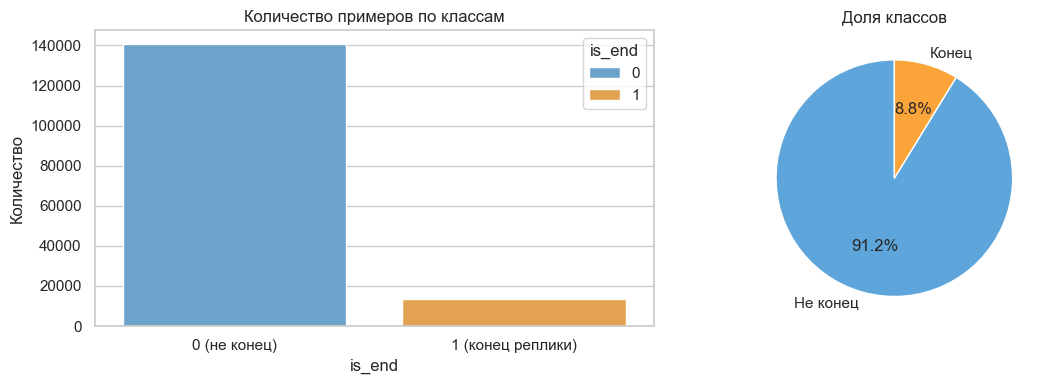


График сохранён: reports/figures/class_balance.png


In [29]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Слева — countplot (абсолютные значения)
sns.countplot(data=df, x='is_end', hue='is_end', ax=axes[0], palette=['#5DA5DA', '#FAA43A'])
axes[0].set_title('Количество примеров по классам')
axes[0].set_xlabel('is_end')
axes[0].set_ylabel('Количество')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['0 (не конец)', '1 (конец реплики)'])

# Справа — pie chart (доли)
class_props.plot.pie(
    ax=axes[1],
    labels=['Не конец', 'Конец'],
    autopct='%1.1f%%',
    colors=['#5DA5DA', '#FAA43A'],
    startangle=90
)
axes[1].set_title('Доля классов')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('../reports/figures/class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nГрафик сохранён: reports/figures/class_balance.png")
